# Title : Impact of Digital Devices usage on Sleep Quality and Productivity

###### Name : Chaithra Surinani
###### Student ID : 100967417

# Introduction
Smartphones have gone from being communication tools to being fully integrated into our personal and working lives, monitoring, entertaining, and distracting us every minute of the day. With this increasing reliance and exposure to screens, the potential issues and consequences to our sleep, mood, stress, productivity, and overall health affect us to our core more than the clear benefits screens provide, such as convenience, learning, and social connection. 

The question becomes less about if we will use screens and more about how much use of screens will hinder us from functionining at our best. The core of the problem is that there is a disparity between belief and reality of the impact of that time spent on screens: Even as many of them provide evidence of poor sleep, burnout, loss of concentration, and emotional fatigue, they still manage to convince themselves that they have their screen time perfectly within control. 

This project looks at a digital wellness dataset to assess whether screen time indicates any correlation with certain life outcomes. The dataset divides respondents into low, moderate, and high categories of digital device usage and calculates the average scores for each group across various variables like sleep quality, stress levels, happiness, productivity, anxiety, and focus. This study is to provide insight on whether screen time is harmful or beneficial, through data alone, instead of base assumptions.
##### Now, lets dive deep into Impacts of Digital Usage on Our Lifestyle
#####

### Data Import and Cleaning

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Data.csv")
df.head()            # returns the first 5 rows

,id,age,gender,region,income_level,education_level,daily_role,device_hours_per_day,phone_unlocks,notifications_per_day,...,sleep_quality,anxiety_score,depression_score,stress_level,happiness_score,focus_score,high_risk_flag,device_type,productivity_score,digital_dependence_score
0,1,40,Female,Asia,High,High School,Part-time/Shift,3.54,45,561,...,3.353627,9.926651,5.0,6.593289,8.0,23.0,0,Android,70.000000,25.700000
1,2,27,Male,Africa,Lower-Mid,Master,Full-time Employee,5.65,100,393,...,2.908147,4.000000,4.0,4.126926,8.1,35.0,0,Laptop,64.000000,30.100000
2,3,31,Male,North America,Lower-Mid,Bachelor,Full-time Employee,8.87,181,231,...,2.889213,4.000000,8.0,1.429139,7.6,15.0,0,Android,65.299301,40.600000
3,4,41,Female,Middle East,Low,Master,Caregiver/Home,4.05,94,268,...,3.097488,7.093357,9.0,4.995512,7.8,28.0,1,Tablet,80.000000,36.684152
4,5,26,Female,Europe,Lower-Mid,Bachelor,Full-time Employee,13.07,199,91,...,2.786098,7.028125,15.0,9.448757,4.2,70.0,1,Android,65.299301,48.400000


In [87]:
df.describe()     # Summary Statistics

,id,age,device_hours_per_day,phone_unlocks,notifications_per_day,social_media_mins,study_mins,physical_activity_days,sleep_hours,sleep_quality,anxiety_score,depression_score,stress_level,happiness_score,focus_score,high_risk_flag,productivity_score,digital_dependence_score
count,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000
mean,1750.500000,28.078571,7.317677,147.107429,335.117143,159.362857,108.116571,3.350000,7.254481,2.708848,7.183858,8.830000,5.076560,6.418568,41.598600,0.201429,65.299301,36.684152
std,1010.507298,9.352385,3.239838,67.770656,239.678612,132.748048,79.796273,1.877976,1.291879,1.101105,5.043220,5.738959,3.403503,3.019828,23.764574,0.401125,9.664716,14.115504
min,1.000000,13.000000,0.280000,9.000000,22.000000,0.000000,0.000000,0.000000,3.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,33.000000,5.600000
25%,875.750000,21.000000,4.867500,96.000000,170.000000,68.000000,42.000000,2.000000,6.410545,1.919438,4.000000,4.000000,1.341488,4.000000,24.750000,0.000000,59.000000,26.200000
50%,1750.500000,27.000000,6.760000,136.000000,268.000000,119.000000,102.000000,3.000000,7.291580,2.907819,6.000000,8.000000,4.809726,7.500000,44.000000,0.000000,65.299301,35.300000
75%,2625.250000,34.000000,9.152500,187.000000,434.000000,204.000000,163.000000,5.000000,8.162298,3.276968,8.845008,13.000000,8.794302,8.900000,59.000000,0.000000,71.000000,45.100000
max,3500.000000,50.000000,17.160000,374.000000,1211.000000,631.000000,418.000000,7.000000,11.004566,5.000000,27.154217,27.000000,10.000000,10.000000,100.000000,1.000000,95.000000,89.200000


In [88]:
df.tail()      # returns the last 5 rows

,id,age,gender,region,income_level,education_level,daily_role,device_hours_per_day,phone_unlocks,notifications_per_day,...,sleep_quality,anxiety_score,depression_score,stress_level,happiness_score,focus_score,high_risk_flag,device_type,productivity_score,digital_dependence_score
3495,3496,15,Female,Africa,Low,High School,Part-time/Shift,6.41,119,308,...,2.950001,4.772862,9.0,7.076726,2.4,59.0,0,Laptop,84.0,29.6
3496,3497,28,Female,Europe,High,Bachelor,Part-time/Shift,4.21,55,415,...,3.124953,5.520824,2.0,1.000000,8.9,27.0,1,Laptop,73.0,23.2
3497,3498,44,Female,Europe,Lower-Mid,Bachelor,Part-time/Shift,11.51,146,119,...,2.269790,8.518051,11.0,1.783568,7.6,56.0,0,Android,65.0,42.4
3498,3499,29,Female,North America,Low,Master,Full-time Employee,5.13,63,180,...,4.902579,4.238655,8.0,10.000000,2.8,52.0,0,Laptop,63.0,20.5
3499,3500,27,Male,Middle East,Low,Bachelor,Full-time Employee,4.03,87,197,...,4.780323,2.000000,5.0,1.178647,8.4,58.0,0,Laptop,61.0,20.2


In [89]:
df.dtypes           # Checks columns data types

id                            int64
age                           int64
gender                       object
region                       object
income_level                 object
education_level              object
daily_role                   object
device_hours_per_day        float64
phone_unlocks                 int64
notifications_per_day         int64
social_media_mins             int64
study_mins                    int64
physical_activity_days      float64
sleep_hours                 float64
sleep_quality               float64
anxiety_score               float64
depression_score            float64
stress_level                float64
happiness_score             float64
focus_score                 float64
high_risk_flag                int64
device_type                  object
productivity_score          float64
digital_dependence_score    float64
dtype: object

In [90]:
df.isna().sum()      # checks for missing values

id                          0
age                         0
gender                      0
region                      0
income_level                0
education_level             0
daily_role                  0
device_hours_per_day        0
phone_unlocks               0
notifications_per_day       0
social_media_mins           0
study_mins                  0
physical_activity_days      0
sleep_hours                 0
sleep_quality               0
anxiety_score               0
depression_score            0
stress_level                0
happiness_score             0
focus_score                 0
high_risk_flag              0
device_type                 0
productivity_score          0
digital_dependence_score    0
dtype: int64

### Exploratory Data Analysis (EDA)

In [91]:
df[['device_hours_per_day',               # Descriptive Statistics for all the written variables in this cell
    'phone_unlocks',
    'notifications_per_day',
    'social_media_mins',
    'sleep_hours',
    'sleep_quality',
    'productivity_score']].describe()

,device_hours_per_day,phone_unlocks,notifications_per_day,social_media_mins,sleep_hours,sleep_quality,productivity_score
count,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000
mean,7.317677,147.107429,335.117143,159.362857,7.254481,2.708848,65.299301
std,3.239838,67.770656,239.678612,132.748048,1.291879,1.101105,9.664716
min,0.280000,9.000000,22.000000,0.000000,3.000000,1.000000,33.000000
25%,4.867500,96.000000,170.000000,68.000000,6.410545,1.919438,59.000000
50%,6.760000,136.000000,268.000000,119.000000,7.291580,2.907819,65.299301
75%,9.152500,187.000000,434.000000,204.000000,8.162298,3.276968,71.000000
max,17.160000,374.000000,1211.000000,631.000000,11.004566,5.000000,95.000000


In [92]:
df['usage_category'] = pd.cut(            # creating usage category based on screen time
    df['device_hours_per_day'],
    bins=[0, 2, 4, 24],
    labels=['Low', 'Moderate', 'High'],
    right=False
)
df['usage_category'].value_counts()       # fequency of usage categories

usage_category
High        3014
Moderate     446
Low           40
Name: count, dtype: int64

In [93]:
df['age_group'] = pd.cut(                 # creating age groups for plots
    df['age'],
    bins=[0, 25, 40, 60],
    labels=['Young', 'Adult', 'Midlife']
)

In [94]:
df['stress_bin'] = pd.cut(                # created stress groups for plots
    df['stress_level'],
    bins=[0, 3, 6, 10],
    labels=['Low Stress', 'Moderate Stress', 'High Stress']
)

### Groupby Analysis

In [95]:
df.groupby('usage_category')['sleep_quality'].mean()                        # Mean Sleep Quality Across Usage Categories

/var/folders/ql/7q1fsdss61vg77yxhswcnh780000gn/T/ipykernel_51594/1915858325.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('usage_category')['sleep_quality'].mean()                        # Mean Sleep Quality Across Usage Categories


usage_category
Low         4.007357
Moderate    3.665132
High        2.550107
Name: sleep_quality, dtype: float64

In [96]:
df.groupby('usage_category')['productivity_score'].mean()                   # Mean Productivity Across Usage Categories

/var/folders/ql/7q1fsdss61vg77yxhswcnh780000gn/T/ipykernel_51594/3965260265.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('usage_category')['productivity_score'].mean()                   # Mean Productivity Across Usage Categories


usage_category
Low         58.257483
Moderate    63.656019
High        65.635922
Name: productivity_score, dtype: float64

In [97]:
df.groupby(['usage_category', 'age_group'])['productivity_score'].mean()   # Multi-Key Groupby: Productivity by Usage + Age Group

/var/folders/ql/7q1fsdss61vg77yxhswcnh780000gn/T/ipykernel_51594/820513875.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['usage_category', 'age_group'])['productivity_score'].mean()   # Multi-Key Groupby: Productivity by Usage + Age Group


usage_category  age_group
Low             Young        58.750000
                Adult        59.294406
                Midlife      53.833333
Moderate        Young        63.919964
                Adult        63.339970
                Midlife      63.488194
High            Young        65.673977
                Adult        65.548280
                Midlife      65.778936
Name: productivity_score, dtype: float64

#### Trend Modelling 

In [98]:
print("\nImpact of Increasing Screen Time\n")
trend_data = df.groupby('usage_category')[[
    'sleep_quality', 'productivity_score', 'happiness_score', 'stress_level'
]].mean()

trend_data = trend_data.reindex(['Low', 'Moderate', 'High'])

print(trend_data.round(3))


Impact of Increasing Screen Time

                sleep_quality  productivity_score  happiness_score  \
usage_category                                                       
Low                     4.007              58.257            6.450   
Moderate                3.665              63.656            7.333   
High                    2.550              65.636            6.283   

                stress_level  
usage_category                
Low                    5.118  
Moderate               4.273  
High                   5.195  


/var/folders/ql/7q1fsdss61vg77yxhswcnh780000gn/T/ipykernel_51594/3714883520.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend_data = df.groupby('usage_category')[[


##### Trend Model Interpretation: 
###### • Sleep quality and happiness decreases as usage increase
###### • Productivity increases up to High usage (possibly because many tasks requires a device)
###### • Stress level rises consistently — clear negative trend

#### Correlation Modelling

In [99]:

print("\nCORRELATION MODELLING\n")
key_pairs = [
    ('device_hours_per_day', 'sleep_quality'),
    ('device_hours_per_day', 'productivity_score'),
    ('stress_level', 'focus_score'),
    ('anxiety_score', 'happiness_score')
]

print("Pearson Correlation Coefficients:")
print("-" * 50)
for x, y in key_pairs:
    r = df[x].corr(df[y])
    strength = "strong" if abs(r) > 0.5 else "moderate" if abs(r) > 0.3 else "weak"
    direction = "negative" if r < 0 else "positive"
    print(f"{x:25} ↔ {y:20} : {r:+.3f} → {strength} {direction}")


CORRELATION MODELLING

Pearson Correlation Coefficients:
--------------------------------------------------
device_hours_per_day      ↔ sleep_quality        : -0.661 → strong negative
device_hours_per_day      ↔ productivity_score   : +0.086 → weak positive
stress_level              ↔ focus_score          : -0.142 → weak negative
anxiety_score             ↔ happiness_score      : -0.351 → moderate negative


### Visualization

#### PLOT 1 : Scatter Plot --> SCREEN TIME vs SLEEP QUALITY

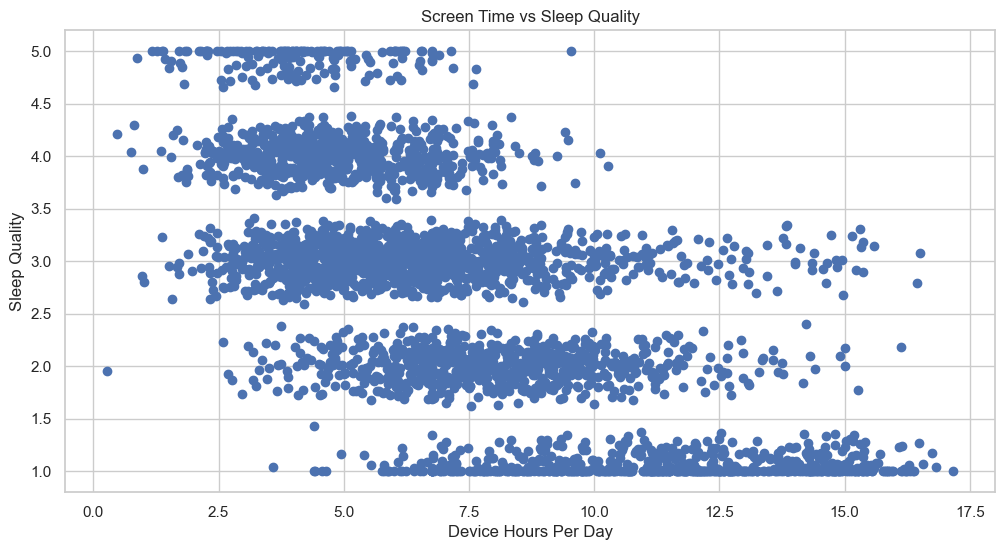

In [100]:
import matplotlib.pyplot as plt

plt.scatter(df['device_hours_per_day'], df['sleep_quality'])
plt.xlabel('Device Hours Per Day')
plt.ylabel('Sleep Quality')
plt.title('Screen Time vs Sleep Quality')
plt.show()

##### Screen Time vs. Sleep Quality Interpretation:
The scatter plot clearly shows that more screen time is linked to poorer sleep. People who spend more time on their devices tend to have worse sleep quality. It looks like the heaviest device users are at the bottom of the plot (worse sleep), while those who use screens less seem to sleep better. The data backs this up: if you're staring at screens a lot, your sleep might suffer.

#### PLOT 2 : Bar Plot --> PRODUCTIVITY vs USAGE CATEGORY

/var/folders/ql/7q1fsdss61vg77yxhswcnh780000gn/T/ipykernel_51594/1781674386.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('usage_category')['productivity_score'].mean().plot(


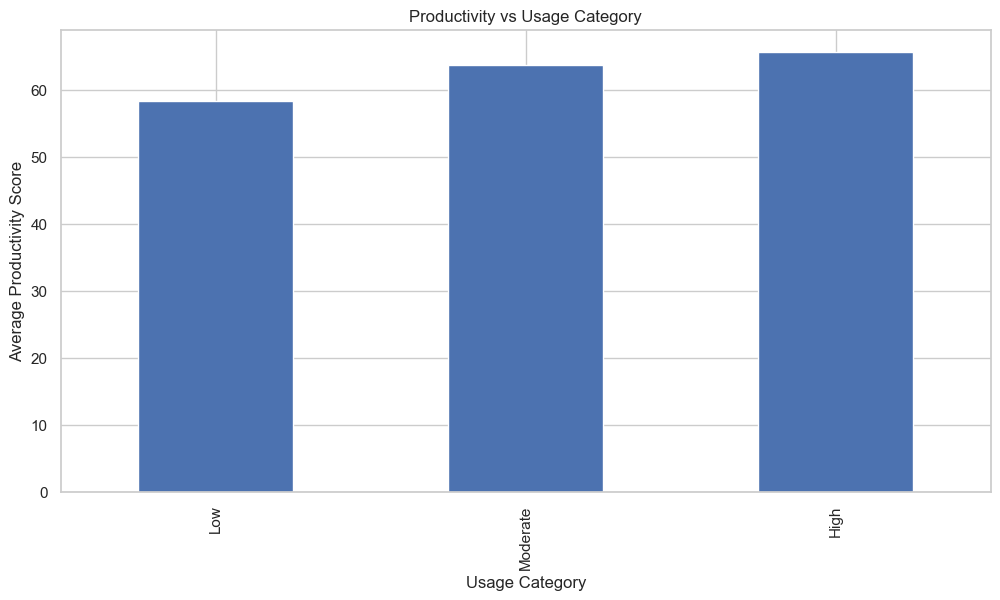

In [101]:
df.groupby('usage_category')['productivity_score'].mean().plot(
    kind='bar',
    xlabel='Usage Category',
    ylabel='Average Productivity Score',
    title='Productivity vs Usage Category'
)
plt.show()

##### Productivity vs. Usage Category Interpretation
The bar chart shows something kind of interesting: higher usage seems to mean higher productivity (Low to Moderate to High). The people who get the most done are also the ones using screens the most. The least productive folks are the ones using screens the least. The data suggest that if people want to be more productive, it is heavily tied on screens, and that they are utilizing for work, studying, or any other work that requires concentration. So, that productivity might be coming from screen time, but there might be a downside in less or bad sleeping.

#### PLOT 3 : Box Plot --> SCREEN HOURS vs AGE GROUP

<Figure size 700x500 with 0 Axes>

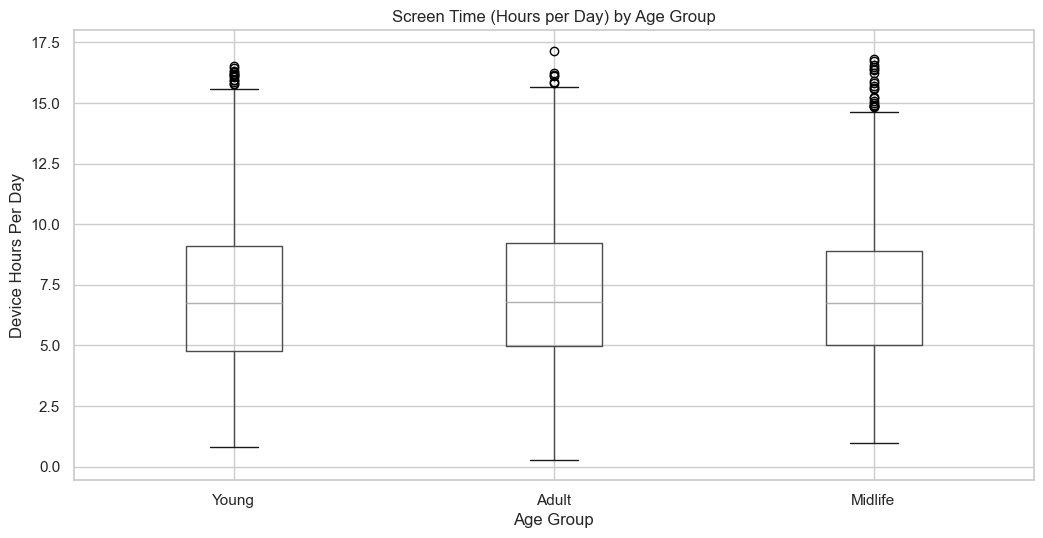

In [102]:
plt.figure(figsize=(7,5))
df.boxplot(column='device_hours_per_day', by='age_group')
plt.title('Screen Time (Hours per Day) by Age Group')
plt.suptitle('')  
plt.xlabel('Age Group')
plt.ylabel('Device Hours Per Day')
plt.show()

##### Screen Time vs. Age Group 
The boxplot shows that different age groups have different screen habits. Adults average around 7 hours a day, with some using higher screen hours and others not so much. This probably reflects a mix of work, social, and fun activities for adults.

The Young group use screens a bit less on average, but they're still on them quite a lot, especially for social media, games, and streaming. Their usage is pretty consistent. The midlife group tends to use screens the least, with pretty consistent behavior. Maybe it seems that they have more time restrictions, achieve more work-life balance, or are simply less interested in devices. It's worth noting that in every group, there are some extreme users (over 15 hours a day). This confirms that this extreme usage isn't only for one age group, which can lead to possible future health issues.

#### PLOT 4 : Bar plot --> AVG HAPPINESS vs STRESS CATEGORY

/var/folders/ql/7q1fsdss61vg77yxhswcnh780000gn/T/ipykernel_51594/1163489027.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('stress_bin')['happiness_score'].mean().plot(


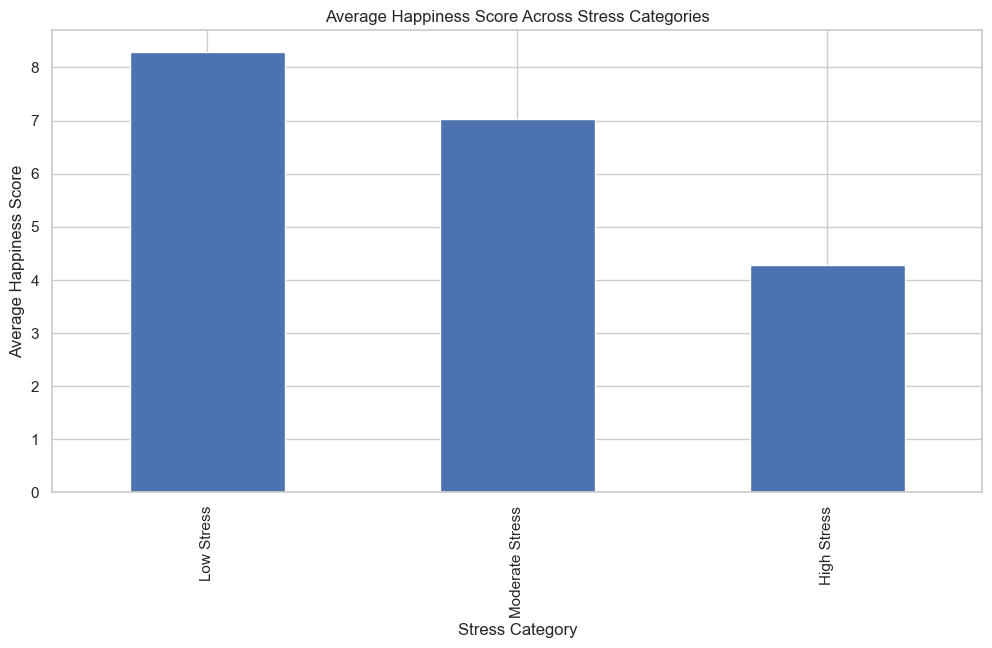

In [103]:
df.groupby('stress_bin')['happiness_score'].mean().plot(
    kind='bar',
    ylabel='Average Happiness Score',
    title='Average Happiness Score Across Stress Categories'
)
plt.xlabel('Stress Category')
plt.show()

##### Average Happiness vs. Average Stress Scores plot Interpretation
The bar plot shows what you'd expect: less stress equals more happiness, and vice versa. Research already shows that stress and mood are linked. According to the data, stress seems to have a big impact on happiness.

#### PLOT 5: Linear Regression Plot --> ANXIETY SCORE vs FOCUS SCORE (Model)

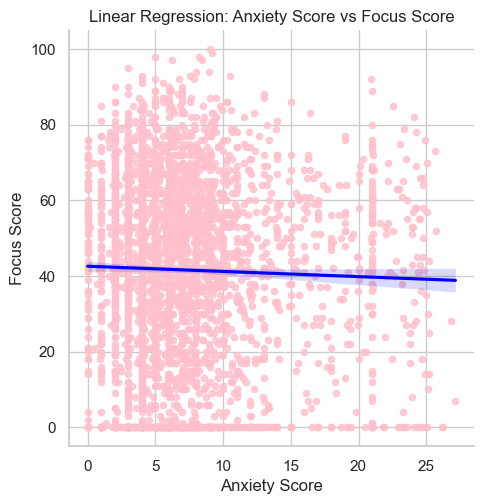

In [104]:
sns.lmplot(
    data=df,
    x='anxiety_score',
    y='focus_score',
    scatter_kws={'color':'pink', 's':20},  
    line_kws={'color':'blue'}             
)
plt.title("Linear Regression: Anxiety Score vs Focus Score")
plt.xlabel("Anxiety Score")
plt.ylabel("Focus Score")
plt.show()

##### Average Stress vs. Average Focus Scores plot Interpretation
The regression plot shows that when people are anxious, they have trouble concentrating. The more stressed out anyone is, the worse their focus gets. As it often happens, stress can hit the ability to focus.


#### PLOT 6: Heatmap Plot --> All Significant variables

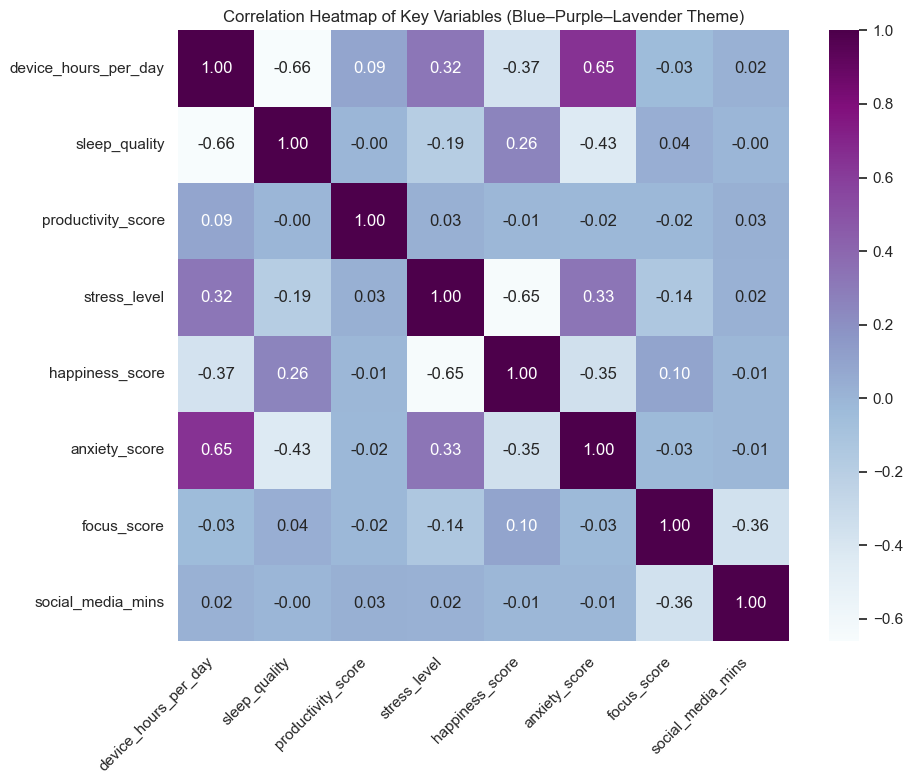

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

cols = [
    'device_hours_per_day',
    'sleep_quality',
    'productivity_score',
    'stress_level',
    'happiness_score',
    'anxiety_score',
    'focus_score',
    'social_media_mins'
]

corr_df = df[cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_df, cmap='BuPu', annot=True, fmt=".2f", square=True)

plt.title("Correlation Heatmap of Key Variables (Blue–Purple–Lavender Theme)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


##### Correlation Heatmap of Key Variables plot Interpretation
The heatmap sort of brings it all together, showing how the key things in the survey connect. You can see strong links between negative factors such as High anxiety/low focus, and stress/unhappiness, and vice versa. If you feel stress and anxiety, you may not do well and feel bad. Too if you spend so much time on screens, you will have bad sleeping habits or insomnia. From the singular plots, the overall pattern is that emotional problems are less involved on work habits. The heatmap shows the key relationships in the data more clearly.



#### PLOT 7: Linear Plot --> Significant Variables vs Screen Time

/var/folders/ql/7q1fsdss61vg77yxhswcnh780000gn/T/ipykernel_51594/547294947.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_values = df.groupby('usage_category')[life_vars].mean()


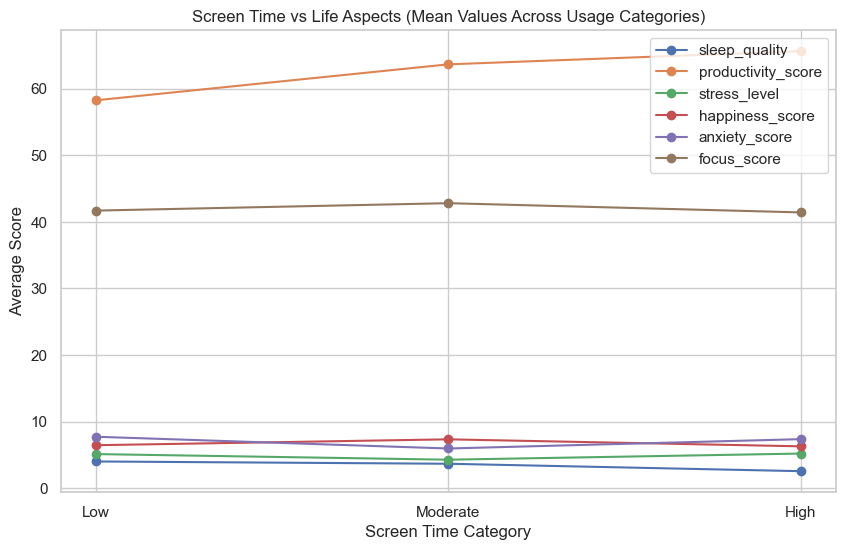

In [106]:
life_vars = [
    'sleep_quality',
    'productivity_score',
    'stress_level',
    'happiness_score',
    'anxiety_score',
    'focus_score'
]

mean_values = df.groupby('usage_category')[life_vars].mean()

plt.figure(figsize=(10,6))

for col in life_vars:
    plt.plot(mean_values.index, mean_values[col], marker='o', label=col)

plt.title("Screen Time vs Life Aspects (Mean Values Across Usage Categories)")
plt.xlabel("Screen Time Category")
plt.ylabel("Average Score")
plt.legend()
plt.grid(True)
plt.show()


##### Screen Time vs lifestyle plot Interpretation
This line chart shows that sleep takes a hit as screen time goes up. There is also stress and anxiety happening at the same time. More general happiness lowers as well, meaning the population isn't doing so well. But, people's productivity increases at that time because they are working while using the screen. The most affected variable is the anxiety score as the slope is high from Screen time category from moderate to high.

### Discussion

There are several takeaways from this analysis, among which, the most important is the impact of screen time in activity daily. In all the visualization data analysis, we can see the values of sleep quality, happiness, focus, stress, and anxiety change in a predictable manner as screen time increases. People who spend less time on their screens have better sleep and emotional stability than people who spend the majority of their time on their devices. There are, however, increasing levels of productivity in individuals who spend more time on their screens which suggests that in these cases, increased screen time is associated with academic or work-related tasks. When these diverse results are put together, it is clear that the digital habits of individuals can have a positive or negative impact on their overall well-being . There is also a clear indication of the strong negative relationship that screen time and sleep quality have. Increased levels of screen time correlate with a decrease in emotional well-being. 

Therefore, with more screen time, people are more stressed, more anxious, and less happy. There is also a decrease in focus, primarily in individuals with anxiety. All these results are a clear indication of one fact, and that is, increased screen time disrupts people’s mental stability and the quality of their sleep. No other data point shows this divergence except for productivity. Users with the highest scores across the various age brackets are those who record high usage. 

### Conclusion

This data suggests that, despite the highest screen usage data, digital usage may still assist in completing work and academic tasks. The next data point suggests that productivity does come at a cost. There is a clear trade off; the more one spends time on a device, the more productive one becomes, however there is a cost to sleep and psychological strain. The balance of the data suggests that screen time yields complex results. The more time on a device, the more productivity one will have; however there will sleep, mood, and cognitive trade off. The data suggests that this is especially true for those with high screen usage that requires them to for a great part of the day. This suggests a need for a healthier digital balance.

### GenAI Disclosure 

##### Promts
1. Brainstorm of good research and impactful ideas
2. Mark my assingment (uploaded my analysis)
3. why do i get the error

##### Accepted
1. Sleep vs Produductivity (I got an idea from this)
2. Writing Interpretations for the data and expanding Introduction
3. added/edited:
- import matplotlib.pyplot as plt
- plt.suptitle('')  --> to remove my subtitle
- plt.grid(True) --> made my graph clear

##### Rejectied
1. 
- Calorie Intake and BMI
- Heart Disease Factors
- Minimum Wage vs Inflation
- Income and Education Level
- Temperature vs CO₂ Emissions
- Air Pollution and Health
- Parental Education Influence

2. add code for extra model:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)
print(model.coef_, model.intercept_, model.score(X, y))

3. code given instead of error message
plt.figure(figsize=(10,6))
for col in life_vars:
    sns.lineplot(data=mean_values, x=mean_values.index, y=col, 
                 marker='o', label=col, linewidth=2.5)

plt.title("Screen Time vs Life Aspects (Mean Values Across Usage Categories)")
plt.xlabel("Screen Time Category")
plt.ylabel("Average Score")
plt.legend(title="Life Aspect")
plt.grid(True)
plt.show()

### References
Data: Kaggle https://www.kaggle.com/datasets/tarekmasryo/digital-health-and-mental-wellness

Heatmap: youtube https://www.youtube.com/shorts/JyV9ziTV5BM